# PDF OCR 시각화 도구

Docling OCR 결과를 인터랙티브하게 시각화하는 노트북입니다.

## JupyterLab 서버 시작 방법

터미널에서 다음 명령어를 실행하여 JupyterLab 서버를 시작하세요:

```bash
# JupyterLab 서버 시작 (포트 8000)
uv run jupyter lab --ip=0.0.0.0 --port=8000 --no-browser
```

출력되는 URL과 토큰을 사용하여 브라우저에서 접속:
- **로컬**: `http://localhost:8000/?token=<your-token>`
- **원격 서버**: SSH 포트 포워딩 후 접속
  ```bash
  ssh -L 8000:localhost:8000 user@server
  ```

## 사전 준비

1. **FastAPI 서버**가 실행 중이어야 합니다:
   ```bash
   uv run uvicorn api:app --host 0.0.0.0 --port 3000
   ```

2. **AWS 자격증명**이 설정되어 있어야 합니다 (S3 접근):
   ```bash
   aws configure
   ```

## 주요 기능

- 📁 **S3 파일 브라우저**: S3 버킷을 탐색하고 PDF 선택
- 🔍 **OCR 처리**: Docling 기반 OCR 실행
- 📊 **바운딩 박스 시각화**: 그림(초록), 테이블(빨강) 영역 표시
- 📄 **텍스트 마크다운**: 추출된 텍스트 미리보기
- 💾 **결과 다운로드**: S3 결과를 로컬로 다운로드

## 1. 라이브러리 임포트 및 설정

In [5]:
import requests
import json
import time
from pathlib import Path
from IPython.display import display, Image as IPImage, HTML
from pdf_parser.s3_browser import create_s3_browser
from pdf_parser.s3_handler import S3Handler

# API 서버 URL
API_BASE_URL = "http://localhost:3000"

# S3 Handler 초기화

s3 = S3Handler()

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


## 2. API 서버 Health Check

In [6]:
# Health check
try:
    response = requests.get(f"{API_BASE_URL}/health", timeout=5)
    print(f"Status Code: {response.status_code}")
    print(f"Response: {response.json()}")
    
    if response.status_code == 200:
        print("\n✅ API 서버가 정상적으로 실행 중입니다!")
    else:
        print("\n⚠️  API 서버 응답이 비정상입니다.")
except Exception as e:
    print(f"❌ API 서버에 접근할 수 없습니다: {e}")
    print("\n💡 서버를 시작하세요:")
    print("   uv run uvicorn api:app --host 0.0.0.0 --port 3000")

Status Code: 200
Response: {'status': 'healthy', 'service': 'document-parser-api', 'version': '0.2.0', 'supported_formats': {'pdf': ['.pdf'], 'office': ['.pptx', '.ods', '.docx', '.xlsx', '.odt', '.odp', '.rtf']}}

✅ API 서버가 정상적으로 실행 중입니다!


## 3. S3 파일 브라우저로 PDF 선택

S3 버킷을 탐색하고 OCR을 실행할 PDF를 선택하세요.

In [14]:
# 초기 S3 경로 설정 (실제 경로로 변경하세요)
INITIAL_S3_PATH = "s3://miraeasset-product-knowledge-graph/zeroin/"
OUTPUT_BASE = "s3://miraeasset-product-knowledge-graph/output_ocr/"

# S3 브라우저 생성
browser = create_s3_browser(initial_path=INITIAL_S3_PATH)

print("\n💡 사용 방법:")
print("  1. 📁 폴더를 클릭하여 하위 폴더로 이동")
print("  2. 📄 PDF 파일을 클릭하여 선택")
print("  3. ↑ Parent 버튼으로 상위 폴더로 이동")
print("  4. 경로를 직접 입력하고 'Go' 버튼 클릭")
print("\n📝 선택한 PDF는 아래 셀에서 OCR 처리할 수 있습니다.")


💡 사용 방법:
  1. 📁 폴더를 클릭하여 하위 폴더로 이동
  2. 📄 PDF 파일을 클릭하여 선택
  3. ↑ Parent 버튼으로 상위 폴더로 이동
  4. 경로를 직접 입력하고 'Go' 버튼 클릭

📝 선택한 PDF는 아래 셀에서 OCR 처리할 수 있습니다.


## 4. OCR 처리 실행

위에서 선택한 PDF에 대해 OCR을 실행하고 바운딩 박스 시각화 이미지를 생성합니다.

In [15]:
# 선택된 PDF 가져오기
selected_pdf = browser.get_selected()

if not selected_pdf:
    print("⚠️  PDF를 먼저 선택해주세요.")
else:
    print(f"📄 선택된 파일: {selected_pdf}")
    print(f"📂 출력 경로: {OUTPUT_BASE}")
    print("\n🔍 OCR 처리 시작...")
    
    # OCR API 요청
    request_data = {
        "inputPath": selected_pdf,
        "outputPath": OUTPUT_BASE,
        "tableMode": "accurate",
        "generateBboxImages": True
    }
    
    start_time = time.time()
    
    try:
        response = requests.post(
            f"{API_BASE_URL}/ocr",
            json=request_data,
            timeout=600  # 10분 타임아웃
        )
        
        elapsed = time.time() - start_time
        
        print(f"⏱️  요청 소요 시간: {elapsed:.2f}초")
        print(f"📊 응답 코드: {response.status_code}")
        
        if response.status_code == 200:
            result = response.json()
            print("\n✅ OCR 처리 완료!")
            print("=" * 80)
            print(f"텍스트 마크다운: {result['textMarkdownUri']}")
            print(f"바운딩 박스 이미지: {len(result.get('bboxImagesUris', []))}개")
            print(f"\n📊 통계:")
            print(f"  - 페이지 수: {result['stats']['pages']}")
            print(f"  - 그림 수: {result['stats']['figures']}")
            print(f"  - 테이블 수: {result['stats']['tables']}")
            print(f"  - Bbox 이미지: {result['stats']['bboxImages']}개")
            print(f"\n⏱️  서버 처리 시간: {result['elapsedSeconds']}초")
            
            # 결과를 전역 변수에 저장 (다음 셀에서 사용)
            ocr_result = result
        else:
            print(f"\n❌ OCR 처리 실패: {response.status_code}")
            print(response.text)
            ocr_result = None
    
    except Exception as e:
        print(f"\n❌ 오류 발생: {e}")
        ocr_result = None

📄 선택된 파일: s3://miraeasset-product-knowledge-graph/zeroin/r3/R3_A0018Z0_001.pdf
📂 출력 경로: s3://miraeasset-product-knowledge-graph/output_ocr/

🔍 OCR 처리 시작...
⏱️  요청 소요 시간: 82.45초
📊 응답 코드: 200

✅ OCR 처리 완료!
텍스트 마크다운: s3://miraeasset-product-knowledge-graph/output_ocr/R3_A0018Z0_001/R3_A0018Z0_001_text.md
바운딩 박스 이미지: 4개

📊 통계:
  - 페이지 수: 4
  - 그림 수: 0
  - 테이블 수: 7
  - Bbox 이미지: 4개

⏱️  서버 처리 시간: 82.42초


## 5. 바운딩 박스 시각화 이미지 표시

S3에서 바운딩 박스 이미지를 다운로드하여 표시합니다.
- **초록색**: 그림(Figure) 영역
- **빨간색**: 테이블(Table) 영역

🖼️  바운딩 박스 이미지 표시 (4개)


📄 페이지 1


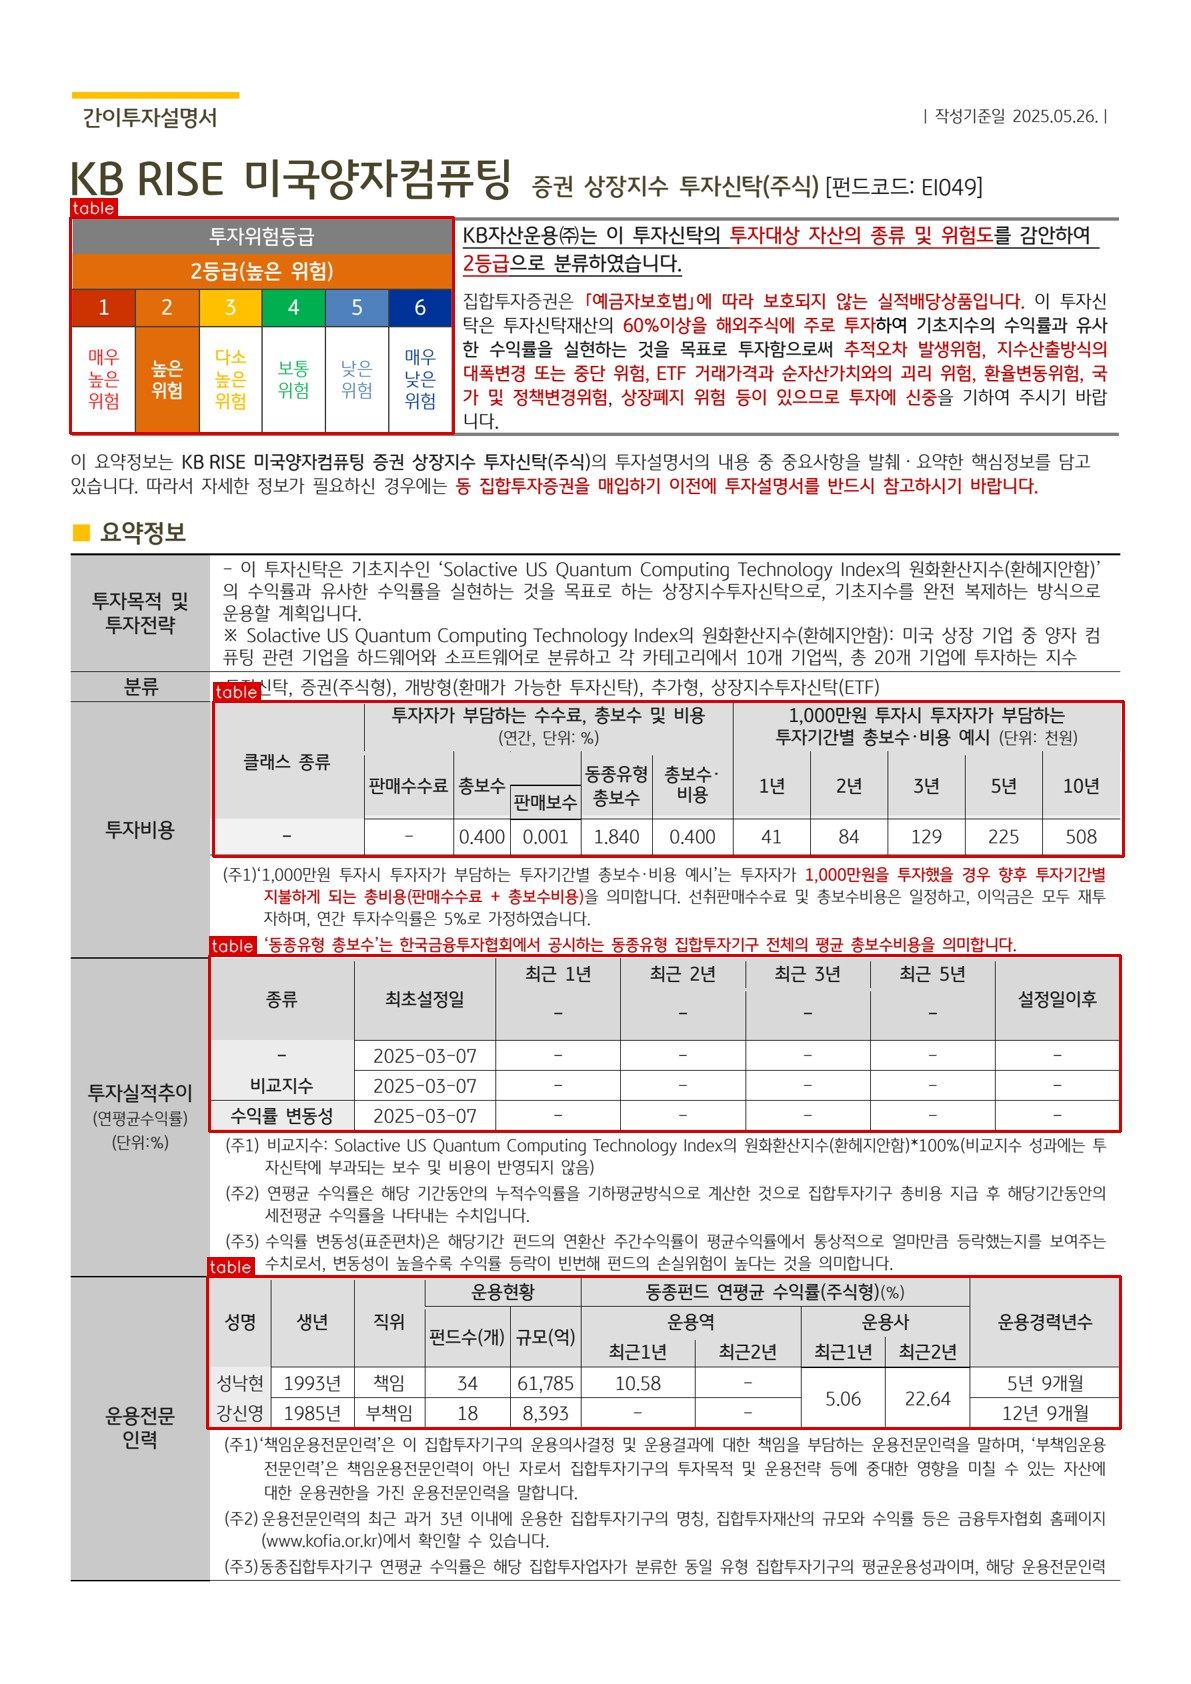


📄 페이지 2


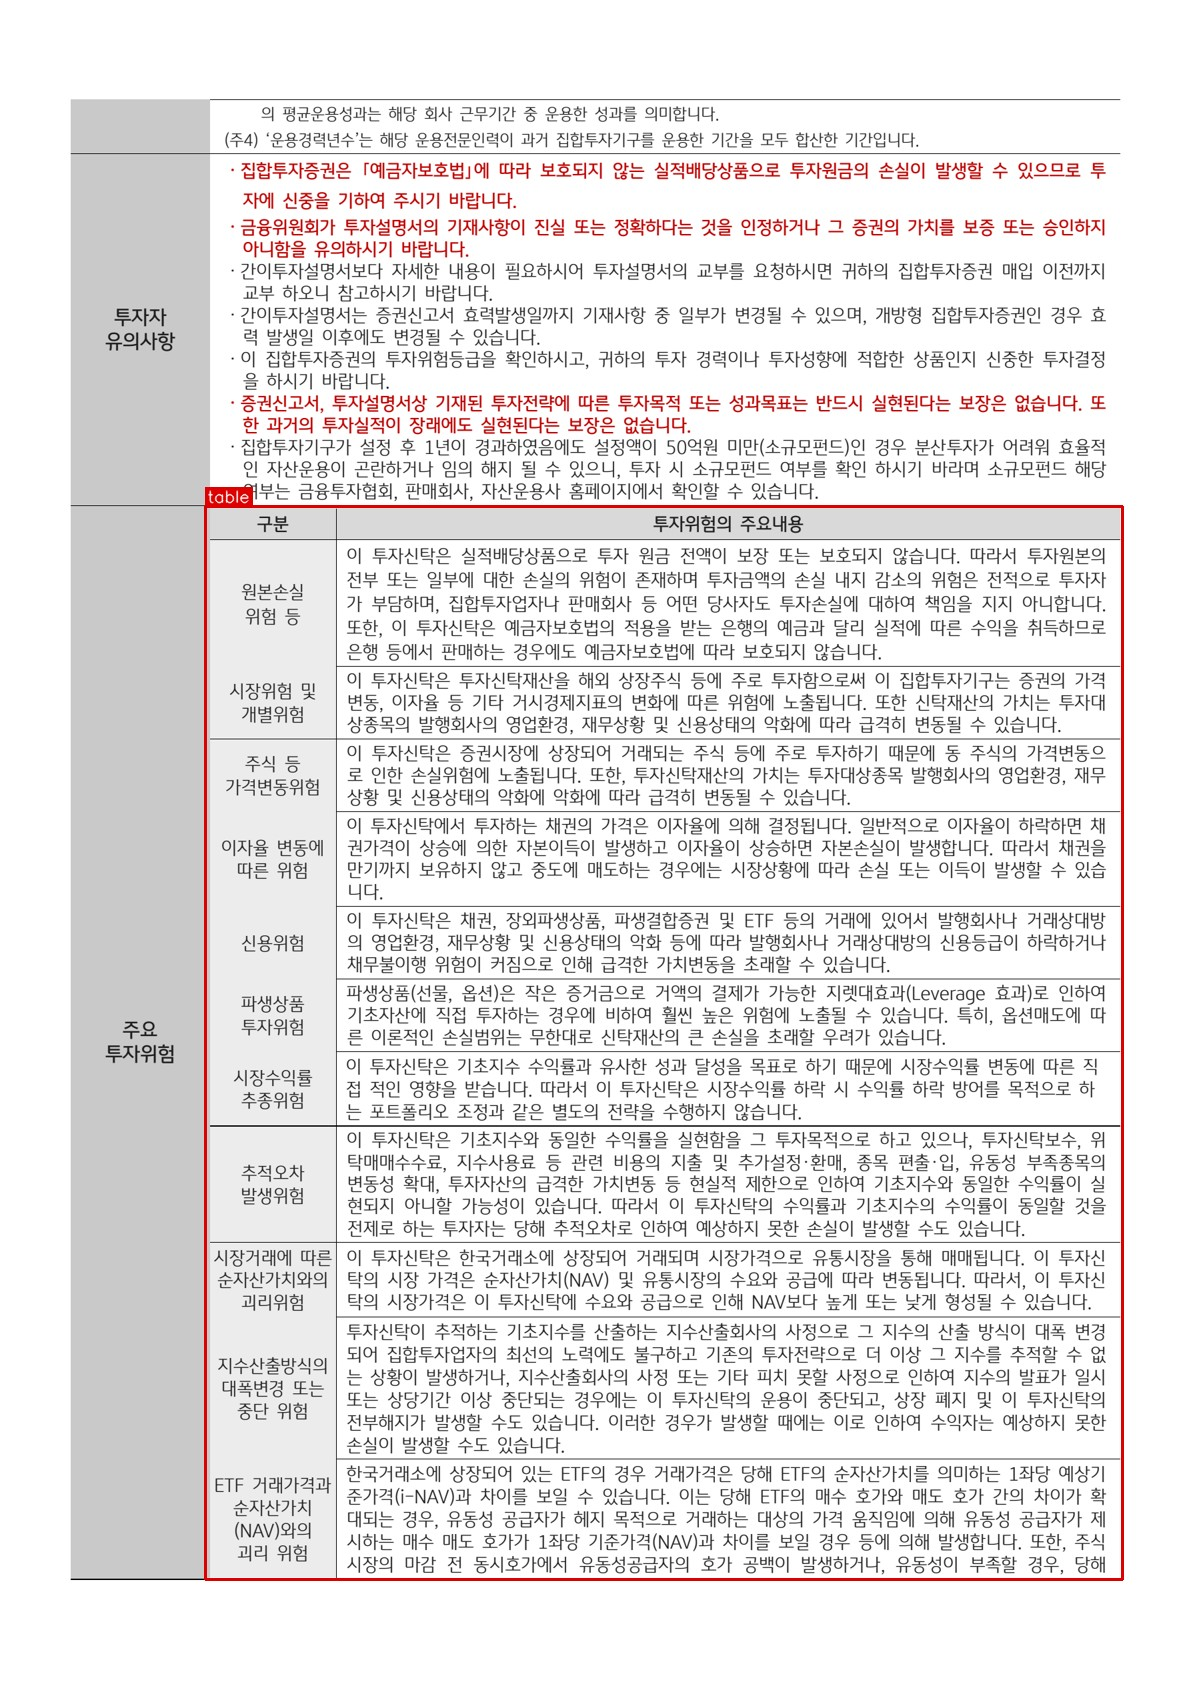


📄 페이지 3


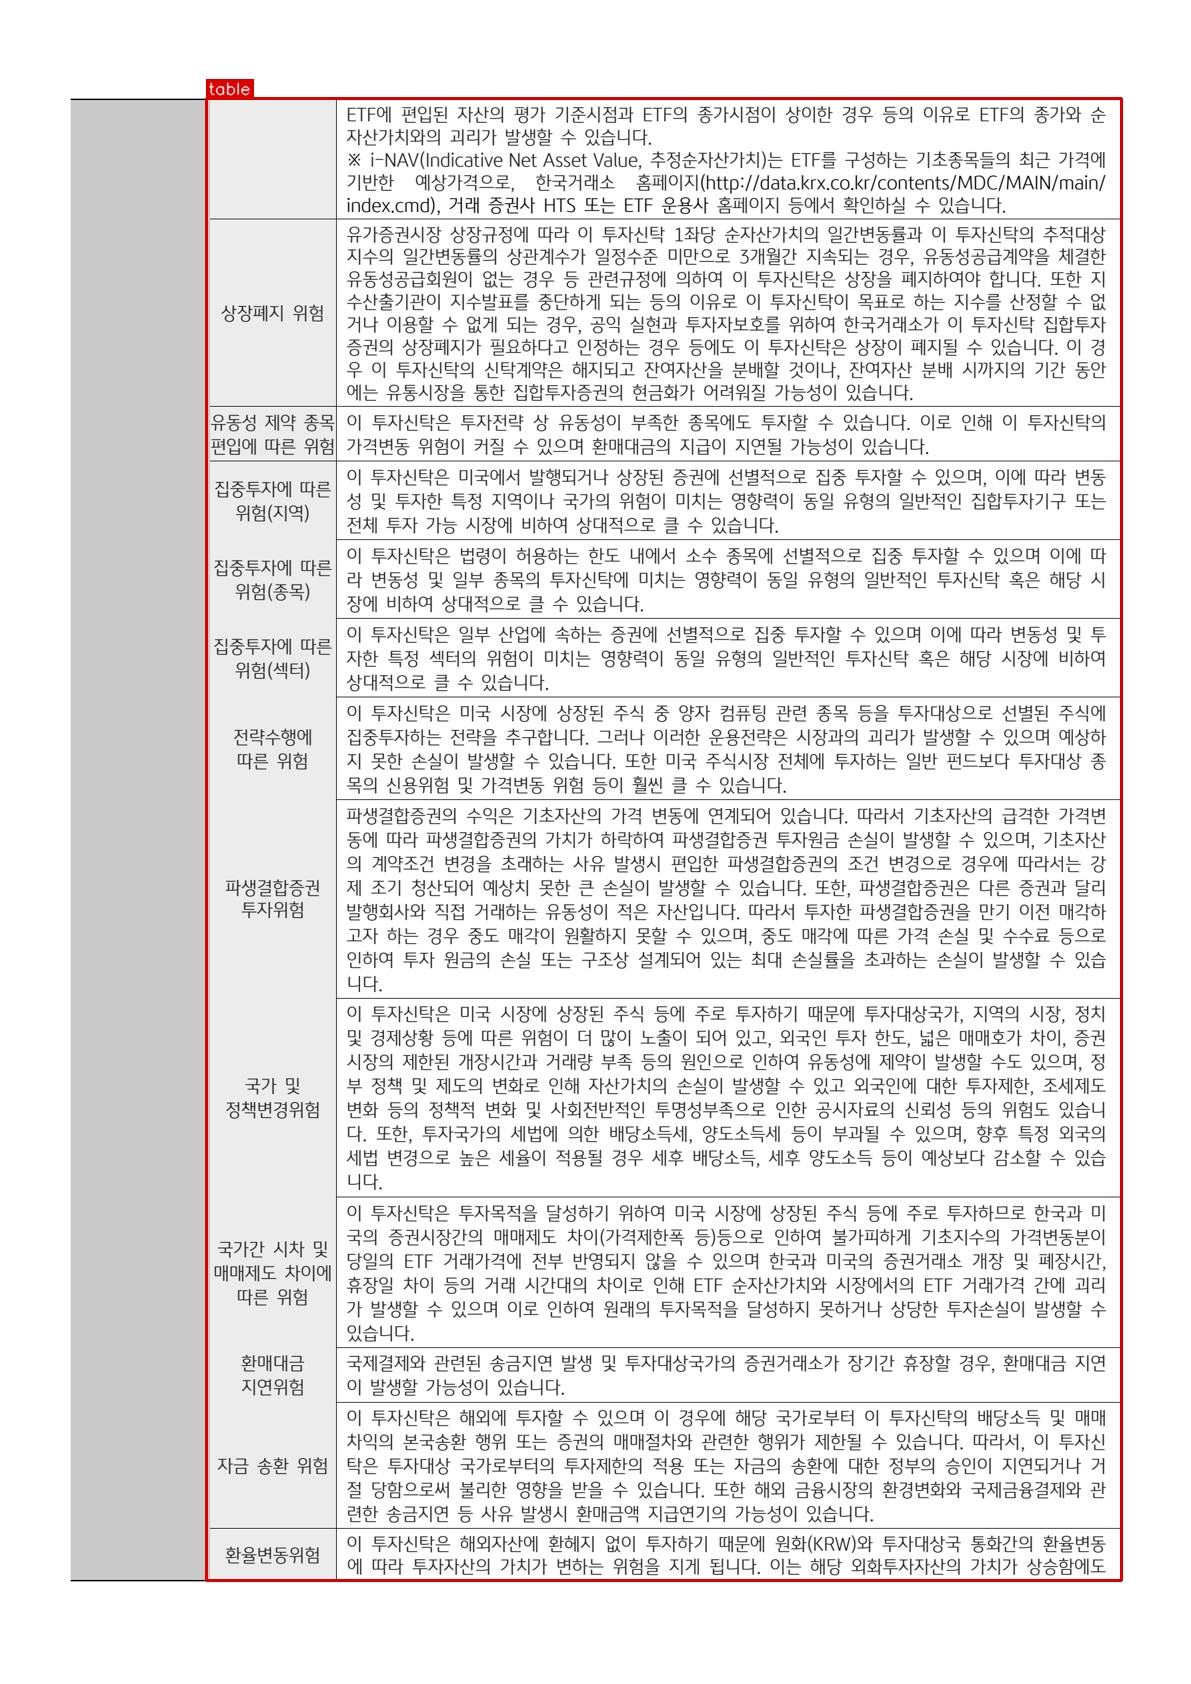


📄 페이지 4


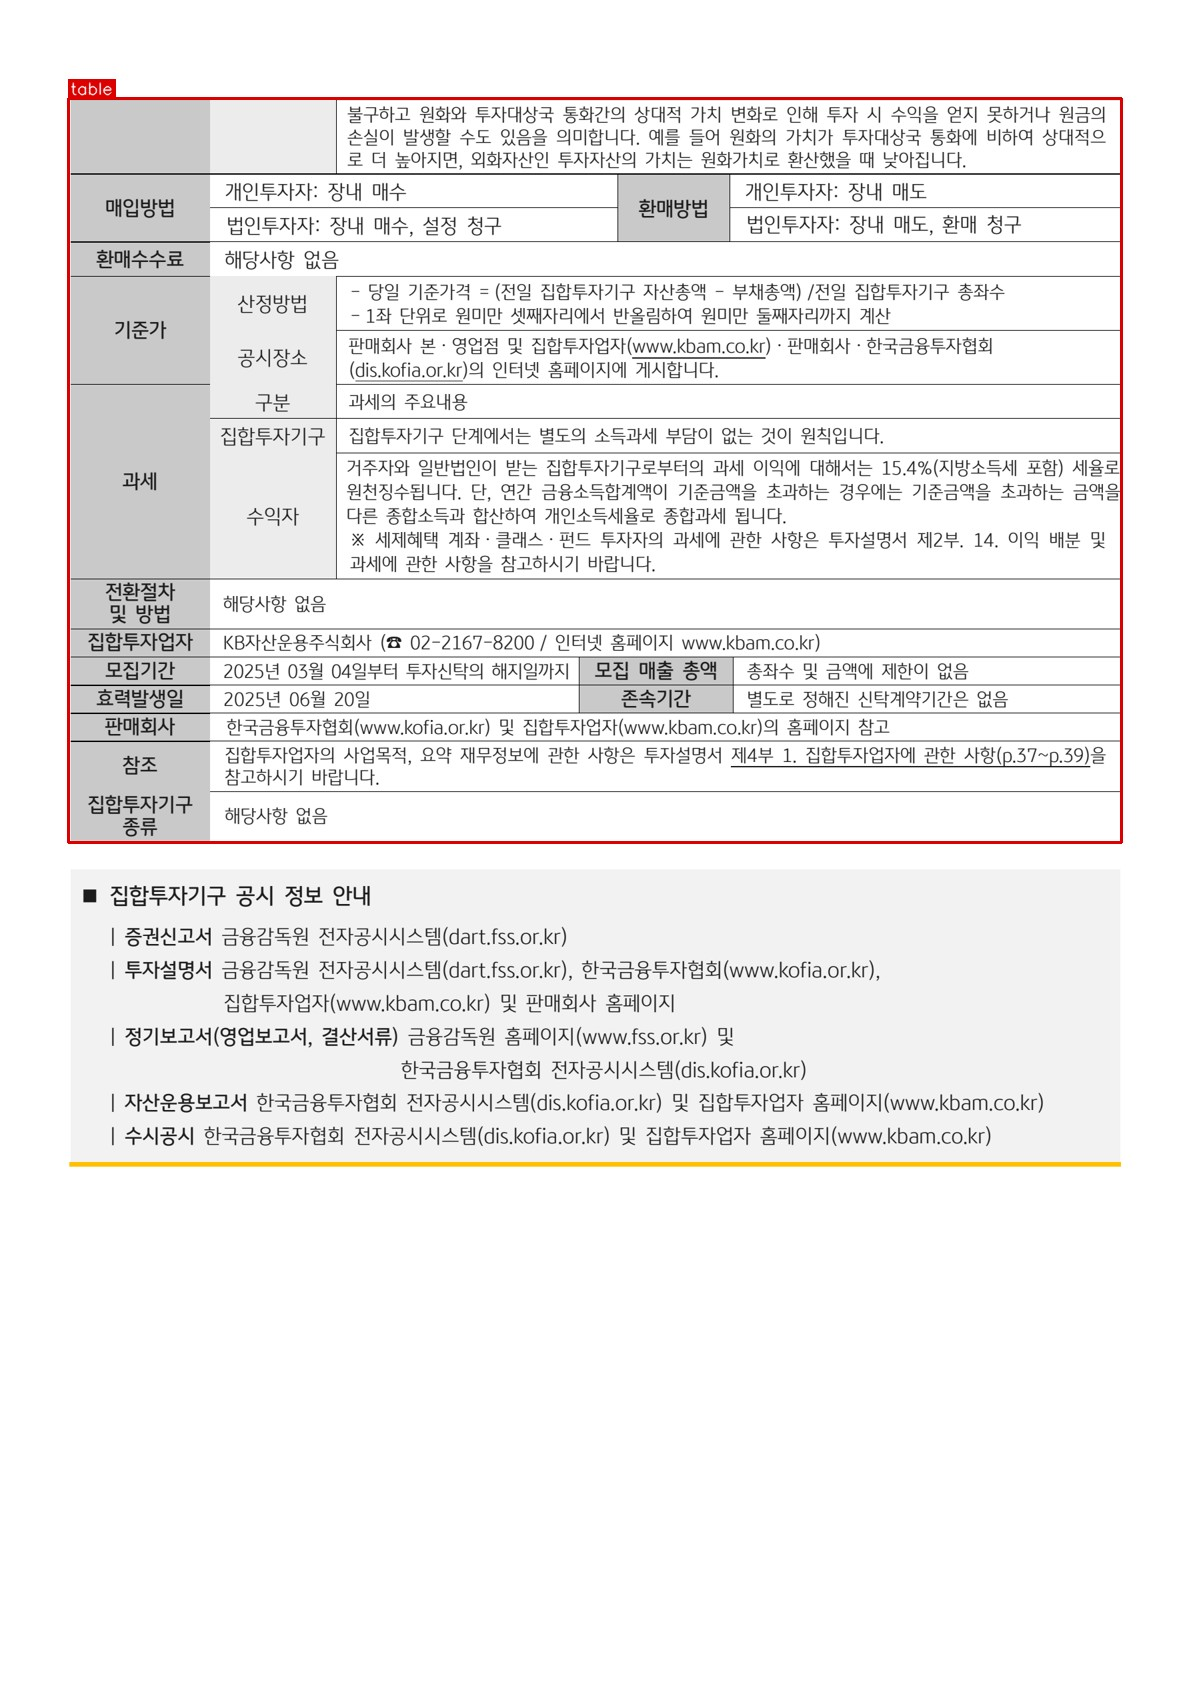


✅ 4개 이미지 표시 완료


In [16]:
if 'ocr_result' not in locals() or not ocr_result:
    print("⚠️  먼저 OCR 처리를 실행해주세요.")
elif not ocr_result.get('bboxImagesUris'):
    print("⚠️  바운딩 박스 이미지가 생성되지 않았습니다.")
else:
    bbox_uris = ocr_result['bboxImagesUris']
    print(f"🖼️  바운딩 박스 이미지 표시 ({len(bbox_uris)}개)\n")
    
    # 임시 디렉토리에 다운로드
    temp_bbox_dir = Path("./temp_bbox")
    temp_bbox_dir.mkdir(exist_ok=True)
    
    for i, uri in enumerate(sorted(bbox_uris), 1):
        # 페이지 번호 추출
        page_no = i
        
        try:
            # S3에서 다운로드
            bucket, key = s3.parse_s3_uri(uri)
            local_path = temp_bbox_dir / Path(key).name
            
            response = s3._client.get_object(Bucket=bucket, Key=key)
            img_bytes = response['Body'].read()
            local_path.write_bytes(img_bytes)
            
            # 이미지 표시
            print(f"\n{'='*80}")
            print(f"📄 페이지 {page_no}")
            print(f"{'='*80}")
            display(IPImage(filename=str(local_path), width=800))
            
        except Exception as e:
            print(f"❌ 페이지 {page_no} 이미지 로드 실패: {e}")
    
    print(f"\n✅ {len(bbox_uris)}개 이미지 표시 완료")

## 6. Cross-Page Table Merger 실험

**문제:** Docling OCR은 페이지 단위로 처리하여, 여러 페이지에 걸친 표를 별도 테이블로 인식

**해결:** OCR 결과(마크다운)를 후처리하여 cross-page 테이블을 자동 병합

**병합 기준:**
1. 인접 페이지 (N페이지 하단 + N+1페이지 상단)
2. 동일한 컬럼 수
3. 다음 페이지 테이블에 헤더가 없음 (continuation 신호)
4. 양쪽 모두 헤더 있으면 유사도 체크 (반복된 헤더)

**장점:**
- 이미지 병합 불필요 (처리 시간 증가 없음)
- 기존 Docling OCR 결과 그대로 활용
- 후처리이므로 기존 파이프라인에 쉽게 통합

In [17]:
# table_merger 모듈 테스트
from pdf_parser.table_merger import merge_cross_page_tables, _extract_tables_from_page

# 테스트용 샘플: 2페이지에 걸친 테이블
test_md = """# Page 1 Content

Some text here.

| Name | Age | City |
| --- | --- | --- |
| Alice | 30 | Seoul |
| Bob | 25 | Busan |
<!-- page-break -->
| Carol | 28 | Daegu |
| Dave | 35 | Incheon |

Some more text on page 2.

| Product | Price |
| --- | --- |
| A | 100 |
"""

merged, stats = merge_cross_page_tables(test_md)

print("=== Merge Stats ===")
print(f"Total tables: {stats['total_tables']}")
print(f"Merged groups: {stats['merged_groups']}")
for d in stats['details']:
    print(f"  Pages {d['from_page']}-{d['to_page']}: {d['tables_merged']} tables merged")
    print(f"  Header: {d['header_preview']}")

print("\n=== Merged Output ===")
print(merged)

=== Merge Stats ===
Total tables: 3
Merged groups: 1
  Pages 1-2: 2 tables merged
  Header: | Name | Age | City |

=== Merged Output ===
# Page 1 Content

Some text here.

| Name | Age | City |
| --- | --- | --- |
| Alice | 30 | Seoul |
| Bob | 25 | Busan |
| Carol | 28 | Daegu |
| Dave | 35 | Incheon |
<!-- page-break -->

Some more text on page 2.

| Product | Price |
| --- | --- |
| A | 100 |



### 6.1 실제 PDF에 적용: OCR → Table Merger

In [18]:
# 실제 PDF로 Table Merger 테스트
# 1) OCR API로 원본 텍스트 마크다운 가져오기
# 2) table_merger로 후처리
# 3) before/after 비교

S3_PDF_PATH = "s3://miraeasset-product-knowledge-graph/zeroin/r3/R3_A0018Z0_001.pdf"
OUTPUT_BASE = "s3://miraeasset-product-knowledge-graph/output_ocr/"

print(f"📄 대상 PDF: {S3_PDF_PATH}")
print("=" * 80)

# Step 1: OCR API 호출 (또는 이미 실행된 결과 사용)
if 'ocr_result' in locals() and ocr_result:
    print(f"\n✅ 기존 OCR 결과 사용: {ocr_result['textMarkdownUri']}")
    text_md_uri = ocr_result['textMarkdownUri']
else:
    print("\n🔍 OCR API 호출 중...")
    import time
    t0 = time.time()
    resp = requests.post(
        f"{API_BASE_URL}/ocr",
        json={
            "inputPath": S3_PDF_PATH,
            "outputPath": OUTPUT_BASE,
            "tableMode": "accurate",
            "generateBboxImages": False
        },
        timeout=600
    )
    elapsed = time.time() - t0
    
    if resp.status_code == 200:
        ocr_result = resp.json()
        text_md_uri = ocr_result['textMarkdownUri']
        print(f"✅ OCR 완료 ({elapsed:.1f}초)")
        print(f"   테이블: {ocr_result['stats']['tables']}개, 페이지: {ocr_result['stats']['pages']}개")
    else:
        print(f"❌ OCR 실패: {resp.status_code}")
        text_md_uri = None

# Step 2: 텍스트 마크다운 다운로드
if text_md_uri:
    print(f"\n📥 텍스트 마크다운 다운로드: {text_md_uri}")
    raw_md = s3.read_markdown(text_md_uri)
    print(f"   길이: {len(raw_md)} 문자")
    
    # 원본 테이블 수 세기
    raw_table_lines = [l for l in raw_md.split('\n') if l.strip().startswith('|')]
    print(f"   테이블 행 수 (| 시작): {len(raw_table_lines)}행")
    
    print("\n" + "=" * 80)
    print("✅ 다음 셀에서 Table Merger를 적용합니다.")

📄 대상 PDF: s3://miraeasset-product-knowledge-graph/zeroin/r3/R3_A0018Z0_001.pdf

🔍 OCR API 호출 중...
✅ OCR 완료 (81.4초)
   테이블: 7개, 페이지: 4개

📥 텍스트 마크다운 다운로드: s3://miraeasset-product-knowledge-graph/output_ocr/R3_A0018Z0_001/R3_A0018Z0_001_text.md
   길이: 43237 문자
   테이블 행 수 (| 시작): 63행

✅ 다음 셀에서 Table Merger를 적용합니다.


### 6.2 Table Merger 적용 및 Before/After 비교

In [19]:
# Table Merger 적용
if 'raw_md' not in locals() or not raw_md:
    print("⚠️  먼저 상단 셀에서 OCR 결과를 로드해주세요.")
else:
    from pdf_parser.table_merger import merge_cross_page_tables, _extract_tables_from_page
    
    PAGE_BREAK = "<!-- page-break -->"
    
    print("🔍 Table Merger 적용")
    print("=" * 80)
    
    # Before: 원본 분석
    print("\n📄 BEFORE (원본 OCR 결과)")
    print("-" * 80)
    
    pages = raw_md.split(PAGE_BREAK)
    print(f"   총 페이지: {len(pages)}")
    
    all_tables_before = []
    for page_num, page_content in enumerate(pages):
        tables = _extract_tables_from_page(page_content, page_num)
        all_tables_before.extend(tables)
        if tables:
            for t in tables:
                print(f"   페이지 {page_num+1}: 테이블 (행 {t.start_line}, {len(t.rows)}행, {t.col_count}열, 헤더={'O' if t.has_header else 'X'})")
    
    print(f"\n   총 테이블: {len(all_tables_before)}개")
    
    # Merge 실행
    print("\n" + "=" * 80)
    print("\n🔗 Table Merger 실행...")
    merged_md, stats = merge_cross_page_tables(raw_md, PAGE_BREAK)
    
    # After: 병합 결과 분석
    print("\n📄 AFTER (병합 후)")
    print("-" * 80)
    
    pages_after = merged_md.split(PAGE_BREAK)
    all_tables_after = []
    for page_num, page_content in enumerate(pages_after):
        tables = _extract_tables_from_page(page_content, page_num)
        all_tables_after.extend(tables)
        if tables:
            for t in tables:
                print(f"   페이지 {page_num+1}: 테이블 ({len(t.rows)}행, {t.col_count}열, 헤더={'O' if t.has_header else 'X'})")
    
    print(f"\n   총 테이블: {len(all_tables_after)}개")
    
    # 비교 요약
    print("\n" + "=" * 80)
    print("\n📊 비교 요약")
    print("=" * 80)
    print(f"\n   {'항목':<25} {'Before':<15} {'After':<15}")
    print(f"   {'-'*55}")
    print(f"   {'테이블 수':<25} {len(all_tables_before):<15} {len(all_tables_after):<15}")
    
    total_rows_before = sum(len(t.rows) for t in all_tables_before)
    total_rows_after = sum(len(t.rows) for t in all_tables_after)
    print(f"   {'테이블 행 수 합계':<25} {total_rows_before:<15} {total_rows_after:<15}")
    print(f"   {'마크다운 길이':<25} {len(raw_md):<15} {len(merged_md):<15}")
    
    print(f"\n   Merge Stats:")
    print(f"   - Total tables found: {stats['total_tables']}")
    print(f"   - Merged groups: {stats['merged_groups']}")
    
    if stats['details']:
        for d in stats['details']:
            print(f"   - Pages {d['from_page']}-{d['to_page']}: {d['tables_merged']} tables merged")
            print(f"     Header: {d['header_preview']}")
    else:
        print(f"   - (병합 대상 없음)")
    
    if stats['merged_groups'] > 0:
        print(f"\n   ✅ Cross-page 테이블이 성공적으로 병합되었습니다!")
    else:
        print(f"\n   📝 이 PDF에는 cross-page 테이블이 감지되지 않았습니다.")
        print(f"      (다른 PDF로 테스트해보세요)")

🔍 Table Merger 적용

📄 BEFORE (원본 OCR 결과)
--------------------------------------------------------------------------------
   총 페이지: 1
   페이지 1: 테이블 (행 2, 4행, 6열, 헤더=O)
   페이지 1: 테이블 (행 33, 4행, 11열, 헤더=O)
   페이지 1: 테이블 (행 42, 5행, 7열, 헤더=O)
   페이지 1: 테이블 (행 55, 6행, 10열, 헤더=O)
   페이지 1: 테이블 (행 78, 44행, 5열, 헤더=O)

   총 테이블: 5개


🔗 Table Merger 실행...

📄 AFTER (병합 후)
--------------------------------------------------------------------------------
   페이지 1: 테이블 (4행, 6열, 헤더=O)
   페이지 1: 테이블 (4행, 11열, 헤더=O)
   페이지 1: 테이블 (5행, 7열, 헤더=O)
   페이지 1: 테이블 (6행, 10열, 헤더=O)
   페이지 1: 테이블 (44행, 5열, 헤더=O)

   총 테이블: 5개


📊 비교 요약

   항목                        Before          After          
   -------------------------------------------------------
   테이블 수                     5               5              
   테이블 행 수 합계                63              63             
   마크다운 길이                   43237           43237          

   Merge Stats:
   - Total tables found: 5
   - Merged groups: 0
   - (병합 대상 없음

### 6.3 병합된 테이블 내용 확인

In [20]:
# 병합 전/후 테이블 내용 비교
if 'merged_md' not in locals() or not merged_md:
    print("⚠️  먼저 상단 셀에서 Table Merger를 실행해주세요.")
else:
    import pandas as pd
    from IPython.display import display, Markdown
    
    PAGE_BREAK = "<!-- page-break -->"
    
    print("📊 테이블 내용 비교 (Before vs After)")
    print("=" * 100)
    
    # Before 테이블들
    pages_before = raw_md.split(PAGE_BREAK)
    tables_before = []
    for pn, pc in enumerate(pages_before):
        for t in _extract_tables_from_page(pc, pn):
            tables_before.append(t)
    
    # After 테이블들
    pages_after = merged_md.split(PAGE_BREAK)
    tables_after = []
    for pn, pc in enumerate(pages_after):
        for t in _extract_tables_from_page(pc, pn):
            tables_after.append(t)
    
    # Before 테이블 출력
    print(f"\n1️⃣  BEFORE: {len(tables_before)}개 테이블")
    print("-" * 100)
    for i, t in enumerate(tables_before):
        print(f"\n--- 테이블 {i+1} (페이지 {t.page_num+1}, {len(t.rows)}행, 헤더={'O' if t.has_header else 'X'}) ---")
        # 처음 5행만 표시
        preview = '\n'.join(t.rows[:5])
        if len(t.rows) > 5:
            preview += f'\n... ({len(t.rows) - 5}행 더)'
        display(Markdown(preview))
    
    # After 테이블 출력
    print(f"\n\n2️⃣  AFTER: {len(tables_after)}개 테이블")
    print("-" * 100)
    for i, t in enumerate(tables_after):
        print(f"\n--- 테이블 {i+1} (페이지 {t.page_num+1}, {len(t.rows)}행, 헤더={'O' if t.has_header else 'X'}) ---")
        preview = '\n'.join(t.rows[:8])
        if len(t.rows) > 8:
            preview += f'\n... ({len(t.rows) - 8}행 더)'
        display(Markdown(preview))
    
    # 결론
    print("\n" + "=" * 100)
    print("\n🎯 결론")
    print("=" * 100)
    
    if stats['merged_groups'] > 0:
        print(f"\n✅ {stats['merged_groups']}개 그룹이 병합되었습니다!")
        print(f"   테이블 수: {len(tables_before)} → {len(tables_after)}")
        print(f"\n   이 기능은 markdown_builder.py에 이미 통합되어 있습니다.")
        print(f"   run.py 또는 API를 통해 PDF를 처리하면 자동으로 적용됩니다.")
    else:
        print(f"\n📝 이 PDF에서는 cross-page 테이블이 감지되지 않았습니다.")
        print(f"   다른 PDF로 테스트해보세요.")
    
    print(f"\n💡 파이프라인 통합 위치:")
    print(f"   pdf_parser/table_merger.py → merge_cross_page_tables()")
    print(f"   pdf_parser/markdown_builder.py → build() 메서드 내에서 자동 호출")

📊 테이블 내용 비교 (Before vs After)

1️⃣  BEFORE: 5개 테이블
----------------------------------------------------------------------------------------------------

--- 테이블 1 (페이지 1, 4행, 헤더=O) ---


| 투자위험등급 2등급(높은 위험)   | 투자위험등급 2등급(높은 위험)   | 투자위험등급 2등급(높은 위험)   | 투자위험등급 2등급(높은 위험)   | 투자위험등급 2등급(높은 위험)   | 투자위험등급 2등급(높은 위험)   |
|---------------------------------|---------------------------------|---------------------------------|---------------------------------|---------------------------------|---------------------------------|
| 1                               | 2                               | 3                               | 4                               | 5                               | 6                               |
| 매우 높은 위험                  | 높은 위험                       | 다소 높은 위험                  | 보통 위험                       | 낮은 위험                       | 매우 낮은 위험                  |


--- 테이블 2 (페이지 1, 4행, 헤더=O) ---


|             | 투자자가 부담하는 수수료, 총보수 및 비용 (연간, 단위: %)   | 투자자가 부담하는 수수료, 총보수 및 비용 (연간, 단위: %)   | 투자자가 부담하는 수수료, 총보수 및 비용 (연간, 단위: %)   | 투자자가 부담하는 수수료, 총보수 및 비용 (연간, 단위: %)   | 투자자가 부담하는 수수료, 총보수 및 비용 (연간, 단위: %)   | 1,000만원 투자시 투자자가 부담하는 투자기간별 총보수·비용 예시 (단위: 천원)   | 1,000만원 투자시 투자자가 부담하는 투자기간별 총보수·비용 예시 (단위: 천원)   | 1,000만원 투자시 투자자가 부담하는 투자기간별 총보수·비용 예시 (단위: 천원)   | 1,000만원 투자시 투자자가 부담하는 투자기간별 총보수·비용 예시 (단위: 천원)   | 1,000만원 투자시 투자자가 부담하는 투자기간별 총보수·비용 예시 (단위: 천원)   |
|-------------|------------------------------------------------------------|------------------------------------------------------------|------------------------------------------------------------|------------------------------------------------------------|------------------------------------------------------------|-------------------------------------------------------------------------------|-------------------------------------------------------------------------------|-------------------------------------------------------------------------------|-------------------------------------------------------------------------------|-------------------------------------------------------------------------------|
| 클래스 종류 | 판매수수료                                                 | 총보수                                                     | 판매보수                                                   | 동종유형 총보수                                            | 총보수· 비용                                               | 1년                                                                           | 2년                                                                           | 3년                                                                           | 5년                                                                           | 10년                                                                          |
| -           | -                                                          | 0.400                                                      | 0.001                                                      | 1.840                                                      | 0.400                                                      | 41                                                                            | 84                                                                            | 129                                                                           | 225                                                                           | 508                                                                           |


--- 테이블 3 (페이지 1, 5행, 헤더=O) ---


...


--- 테이블 4 (페이지 1, 6행, 헤더=O) ---


|        |        |        | 운용현황   | 운용현황   | 동종펀드 연평균 수익률(주식형) (%)   | 동종펀드 연평균 수익률(주식형) (%)   | 동종펀드 연평균 수익률(주식형) (%)   | 동종펀드 연평균 수익률(주식형) (%)   |              |
|--------|--------|--------|------------|------------|--------------------------------------|--------------------------------------|--------------------------------------|--------------------------------------|--------------|
| 성명   | 생년   | 직위   | 펀드수(개) | 규모(억)   | 운용역                               | 운용역                               | 운용사                               | 운용사                               | 운용경력년수 |
|        |        |        |            |            | 최근1년                              | 최근2년                              | 최근1년                              | 최근2년                              |              |
| 성낙현 | 1993년 | 책임   | 34         | 61,785     | 10.58                                | -                                    | 5.06                                 | 22.64                                | 5년 9개월    |
| 강신영 | 1985년 | 부책임 | 18         | 8,393      | -                                    | -                                    | 5.06                                 | 22.64                                | 12년 9개월   |


--- 테이블 5 (페이지 1, 44행, 헤더=O) ---


| 구분                                          | 투자위험의 주요내용                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
|-----------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| 원본손실 위험 등                              | 이 투자신탁은 실적배당상품으로 투자 원금 전액이 보장 또는 보호되지 않습니다. 따라서 투자원본의 전부 또는 일부에 대한 손실의 위험이 존재하며 투자금액의 손실 내지 감소의 위험은 전적으로 투자자 가 부담하며, 집합투자업자나 판매회사 등 어떤 당사자도 투자손실에 대하여 책임을 지지 아니합니다. 또한, 이 투자신탁은 예금자보호법의 적용을 받는 은행의 예금과 달리 실적에 따른 수익을 취득하므로 은행 등에서 판매하는 경우에도 예금자보호법에 따라 보호되지 않습니다.                                                          |
| 시장위험 및 개별위험                          | 이 투자신탁은 투자신탁재산을 해외 상장주식 등에 주로 투자함으로써 이 집합투자기구는 증권의 가격 변동, 이자율 등 기타 거시경제지표의 변화에 따른 위험에 노출됩니다. 또한 신탁재산의 가치는 투자대 상종목의 발행회사의 영업환경, 재무상황 및 신용상태의 악화에 따라 급격히 변동될 수 있습니다.                                                                                                                                                                                                                                 |
| 주식 등 가격변동위험                          | 이 투자신탁은 증권시장에 상장되어 거래되는 주식 등에 주로 투자하기 때문에 동 주식의 가격변동으 로 인한 손실위험에 노출됩니다. 또한, 투자신탁재산의 가치는 투자대상종목 발행회사의 영업환경, 재무 상황 및 신용상태의 악화에 악화에 따라 급격히 변동될 수 있습니다.                                                                                                                                                                                                                                                            |
| 이자율 변동에 따른 위험                       | 이 투자신탁에서 투자하는 채권의 가격은 이자율에 의해 결정됩니다. 일반적으로 이자율이 하락하면 채 권가격이 상승에 의한 자본이득이 발생하고 이자율이 상승하면 자본손실이 발생합니다. 따라서 채권을 만기까지 보유하지 않고 중도에 매도하는 경우에는 시장상황에 따라 손실 또는 이득이 발생할 수 있습 니다.                                                                                                                                                                                                                       |
| 신용위험                                      | 이 투자신탁은 채권, 장외파생상품, 파생결합증권 및 ETF 등의 거래에 있어서 발행회사나 거래상대방 의 영업환경, 재무상황 및 신용상태의 악화 등에 따라 발행회사나 거래상대방의 신용등급이 하락하거나 채무불이행 위험이 커짐으로 인해 급격한 가치변동을 초래할 수 있습니다.                                                                                                                                                                                                                                                        |
| 파생상품 투자위험                             | 파생상품(선물, 옵션)은 작은 증거금으로 거액의 결제가 가능한 지렛대효과(Leverage 효과)로 인하여 기초자산에 직접 투자하는 경우에 비하여 훨씬 높은 위험에 노출될 수 있습니다. 특히, 옵션매도에 따 른 이론적인 손실범위는 무한대로 신탁재산의 큰 손실을 초래할 우려가 있습니다.                                                                                                                                                                                                                                                  |
... (36행 더)



🎯 결론

📝 이 PDF에서는 cross-page 테이블이 감지되지 않았습니다.
   다른 PDF로 테스트해보세요.

💡 파이프라인 통합 위치:
   pdf_parser/table_merger.py → merge_cross_page_tables()
   pdf_parser/markdown_builder.py → build() 메서드 내에서 자동 호출


## 10. 요약

이 노트북에서 다룬 내용:

1. ✅ API Health Check
2. ✅ S3 파일 브라우저로 PDF 선택
3. ✅ OCR API 호출 및 처리
4. ✅ 바운딩 박스 시각화 이미지 표시
5. ✅ 텍스트 마크다운 미리보기
6. ✅ 전체 결과 다운로드
7. ✅ 통계 요약
8. ✅ 유틸리티 함수

### API 문서

- Swagger UI: http://localhost:3000/docs
- OCR 엔드포인트: POST http://localhost:3000/ocr

### 다음 단계

- **전체 파이프라인**: `api_test.ipynb`에서 LLM 요약 포함 전체 처리
- **로컬 처리**: `pdf_parser_docling.ipynb`에서 로컬 PDF 직접 처리
- **API 서버**: `api.py`에서 `/process` 엔드포인트로 전체 파이프라인 실행